# Taller 6: Morfología matemática

## Cargue y visualice la imagen rect.png.

In [1]:
PATH = './imagenes/'

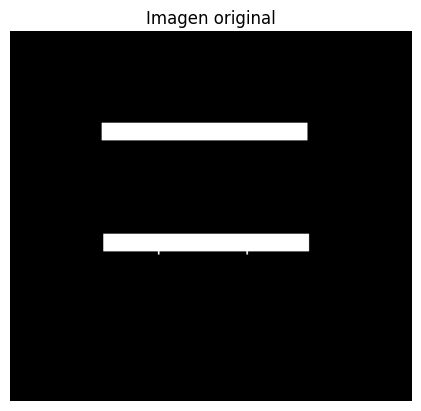

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_rect = cv2.imread(PATH + 'RECT.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_rect, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

## Efectúe la esqueletización de esta imagen. Pruebe cambiando el parámetro opcional method a 'zhang' y luego a 'lee'. Compare los resultados. Explique cómo funcionan ambos algoritmos en términos generales.

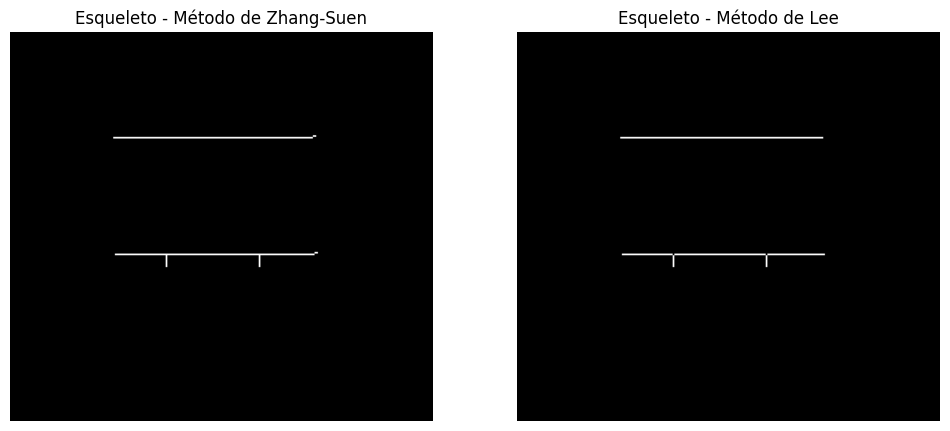

In [ ]:
from skimage.morphology import skeletonize, thin

sk_image_zhang = skeletonize(imagen_rect, method='zhang')
sk_image_lee = skeletonize(imagen_rect, method='lee')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sk_image_zhang, cmap='gray')
ax[0].set_title('Esqueleto - Método de Zhang-Suen')
ax[0].axis('off')
ax[1].imshow(sk_image_lee, cmap='gray')+
ax[1].set_title('Esqueleto - Método de Lee')
ax[1].axis('off')
plt.show()


### Algoritmo de Zhang-Suen:

- **Tipo:** Adelgazamiento iterativo paralelo de dos subiteraciones
- **Funcionamiento:** En cada iteración elimina píxeles del borde que cumplen condiciones específicas sin romper la conectividad. Usa dos subiteraciones alternadas que eliminan píxeles de diferentes bordes (norte-este vs sur-oeste)
- **Condiciones:** Verifica número de vecinos, transiciones 0→1, y que eliminar el píxel no desconecte el objeto
- **Ventajas:** Rápido, produce esqueletos centrados y bien conectados
- **Desventajas:** Puede generar pequeñas espuelas (spurs) en ciertos casos

### Algoritmo de Lee:

- **Tipo:** Adelgazamiento iterativo paralelo
- **Funcionamiento:** Similar a Zhang-Suen pero con reglas diferentes. Elimina píxeles del contorno de manera iterativa usando plantillas (templates) que identifican píxeles eliminables
- **Condiciones:**: Usa 8 plantillas rotadas para identificar píxeles que pueden eliminarse sin afectar la conectividad
- **Ventajas:**  Generalmente produce esqueletos más suaves y con menos artefactos
- **Desventajas:**  Puede ser ligeramente más lento

### Características comunes:

- Ambos preservan la topología (conectividad)
- Producen líneas de 1 píxel de grosor
- Son iterativos hasta que no se puedan eliminar más píxeles
- Paralelos: evalúan todos los píxeles simultáneamente en cada iteración

*Texto generado por Claude Sonnet 4.5.*

**Comparación:** Para esta imagen de rectángulos simples, ambos métodos producen resultados muy parecidos. Solo hay una diferencia y es un píxel en el esqueleto del método Zhang que no hace parte de la línea recta del esqueleto horizontal.

## Efectúe un adelgazamiento de la imagen original. Puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado. Compare el resultado con los de la esqueletización.

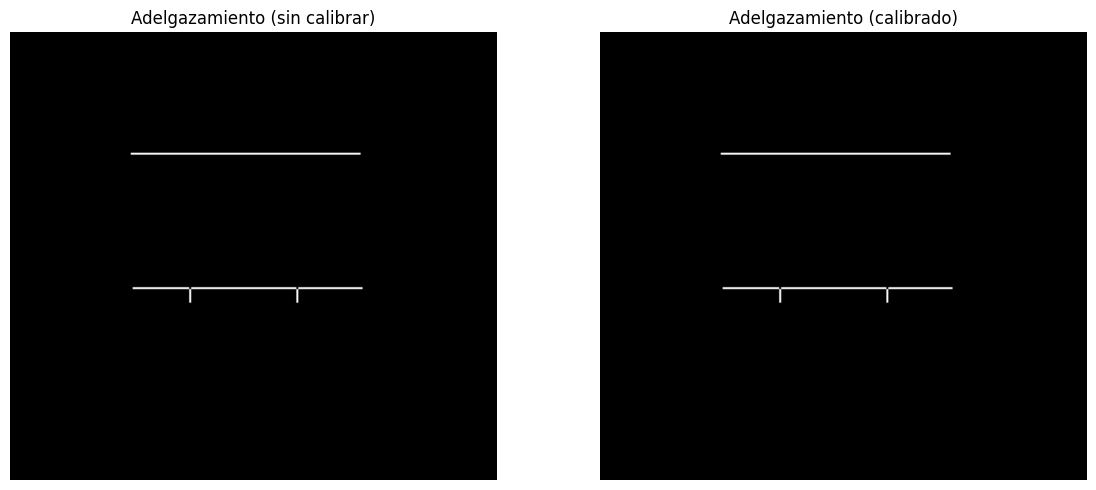

In [6]:
th_image = thin(imagen_rect)
th_image_calibrada = (th_image.astype(np.uint8) * 255)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(th_image, cmap='gray')
axes[0].set_title('Adelgazamiento (sin calibrar)')
axes[0].axis('off')

axes[1].imshow(th_image_calibrada, cmap='gray')
axes[1].set_title('Adelgazamiento (calibrado)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

La imagen de adelgazamiento sin y con calibrado son la misma, debido a que es una imagen binaria sin ruido. Ahora la vamos a comparar la imagen producida por la esqueletización.


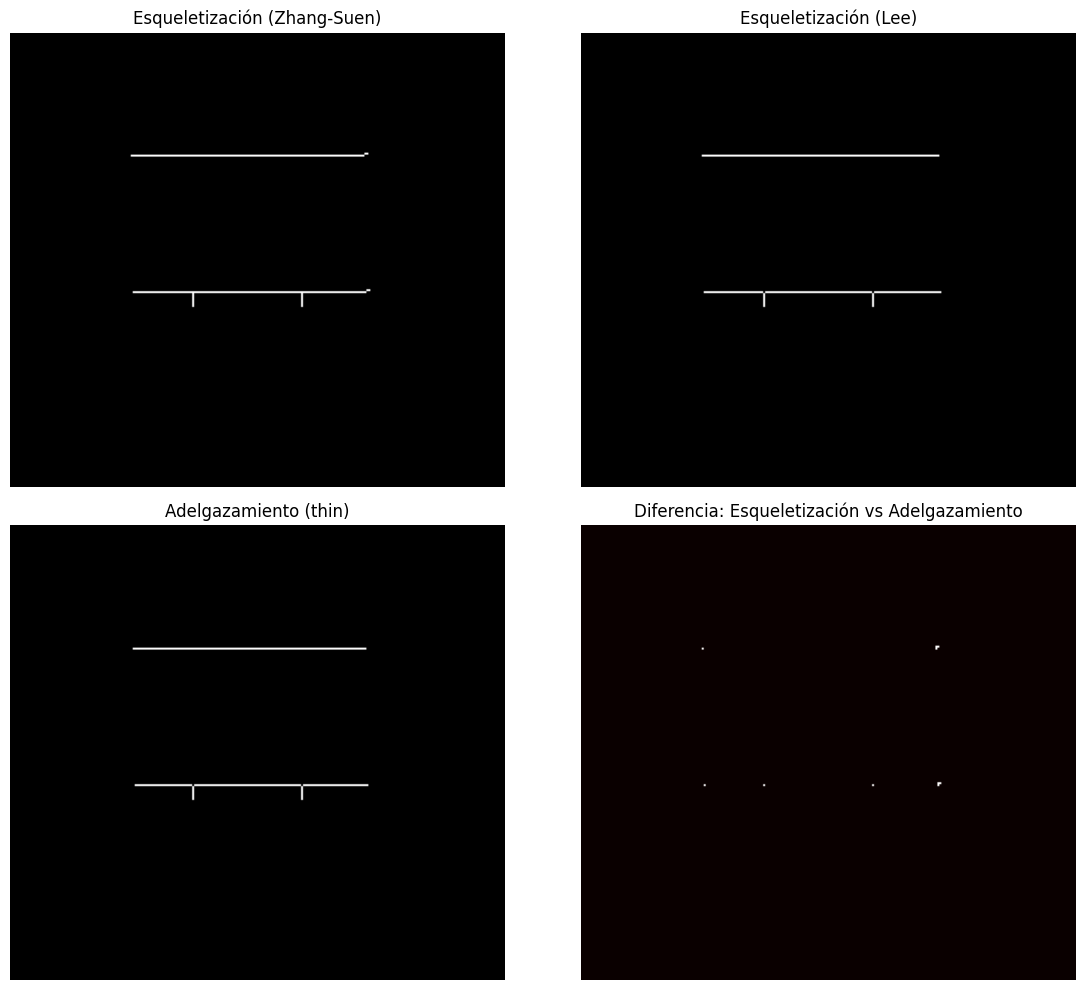

In [7]:
# Comparación completa: Esqueletización vs Adelgazamiento
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(sk_image_zhang, cmap='gray')
axes[0, 0].set_title('Esqueletización (Zhang-Suen)')
axes[0, 0].axis('off')

axes[0, 1].imshow(sk_image_lee, cmap='gray')
axes[0, 1].set_title('Esqueletización (Lee)')
axes[0, 1].axis('off')

axes[1, 0].imshow(th_image_calibrada, cmap='gray')
axes[1, 0].set_title('Adelgazamiento (thin)')
axes[1, 0].axis('off')

# Diferencia entre esqueletización (Zhang) y adelgazamiento
diferencia = (sk_image_zhang.astype(int) - th_image.astype(int))
axes[1, 1].imshow(np.abs(diferencia), cmap='hot')
axes[1, 1].set_title('Diferencia: Esqueletización vs Adelgazamiento')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Vemos que en este caso ambos tratamientos (esqueletización y adelgazamiento) producen resultados casi idénticos.

## Cargue y visualice la imagen angio.png.

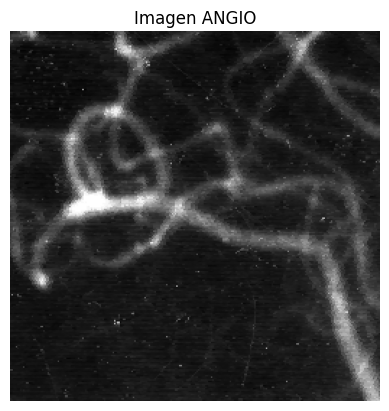

In [8]:
imagen_angio = cv2.imread(PATH + 'ANGIO.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_angio, cmap='gray')
plt.title('Imagen ANGIO')
plt.axis('off')
plt.show()

## Umbralice la imagen utilizando el algoritmo de OTSU, después fíltrela efectuando un cierre y una apertura de la imagen, con una máscara en cruz de 3x3.

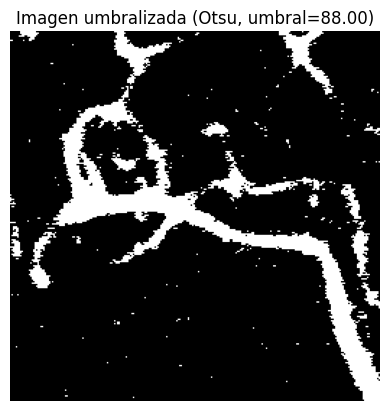

In [13]:
import cv2

thres_value, thres_image_angio = cv2.threshold(imagen_angio, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thres_image_angio, cmap='gray')
plt.title(f'Imagen umbralizada (Otsu, umbral={thres_value:.2f})')
plt.axis('off') 
plt.show()


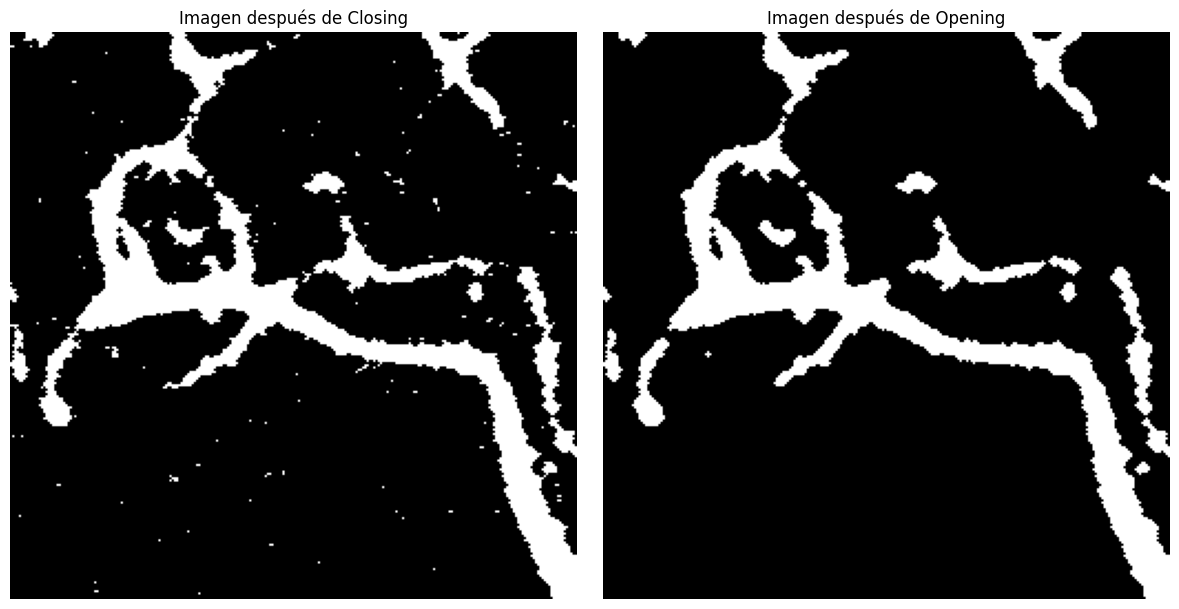

In [11]:
from skimage.morphology import opening, closing
n = 3
cruz = np.full((n, n), 0)
medio = n // 2
cruz[medio, :] = 1
cruz[:, medio] = 1

closed_image = closing(thres_image_angio, cruz)
opened_image = opening(closed_image, cruz)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(closed_image, cmap='gray')
plt.title('Imagen después de Closing')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(opened_image, cmap='gray')
plt.title('Imagen después de Opening')
plt.axis('off')
plt.tight_layout()
plt.show()

## Efectúe su esqueletización y su adelgazamiento. Compare los resultados de estos dos tratamientos.

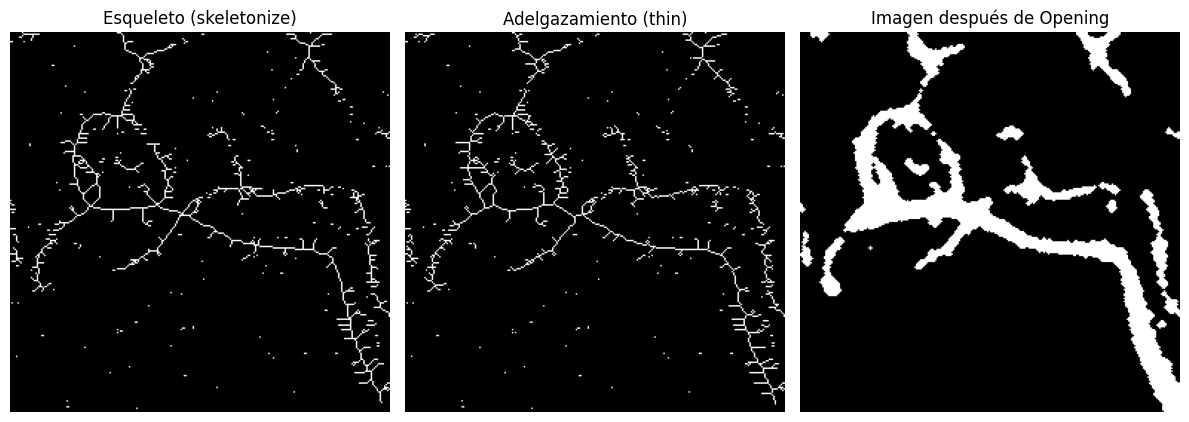

In [15]:
sk_image = skeletonize(thres_image_angio)
th_image = thin(thres_image_angio)

fig, axs = plt.subplots(1, 3, figsize=(12, 6))
axs[0].imshow(sk_image, cmap='gray')
axs[0].set_title('Esqueleto (skeletonize)')
axs[0].axis('off')
axs[1].imshow(th_image, cmap='gray')
axs[1].set_title('Adelgazamiento (thin)')
axs[1].axis('off')
axs[2].imshow(opened_image, cmap='gray')
axs[2].set_title('Imagen después de Opening')
axs[2].axis('off')
plt.tight_layout()
plt.show()

### Comparación de tratamientos:

**Cierre + Apertura:**

- Mantiene el grosor de los vasos
- Elimina ruido pero preserva dimensiones originales
- Útil cuando el grosor es importante

**Esqueletización y Adelgazamiento:**

- Reducen todo a líneas de 1 píxel (eje central)
- Pierden información de grosor
- Útiles para medir longitudes y detectar ramificaciones
- Producen resultados casi idénticos entre sí

## Sobreponga la imagen adelgazada a la imagen angio.png (calculando el máximo entre las dos imágenes) para observar la localización de las líneas con respecto a la imagen inicial. Describa de forma cualitativa el resultado obtenido.

Primero aseguramos que la imagen adelgazada sea de tipo uint8. Luego calculamos el máximo entre la imagen adelgazada y la original.

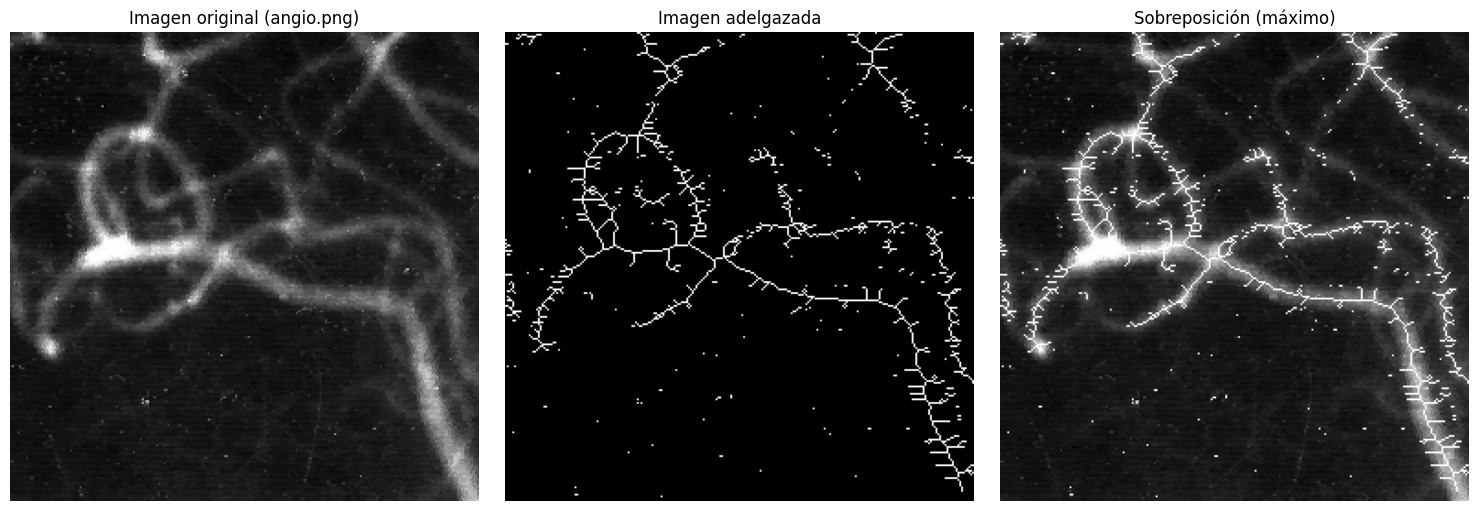

In [16]:
th_image_uint8 = (th_image.astype(np.uint8) * 255)

imagen_sobrepuesta = np.maximum(th_image_uint8, imagen_angio)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagen_angio, cmap='gray')
axes[0].set_title('Imagen original (angio.png)')
axes[0].axis('off')

axes[1].imshow(th_image_uint8, cmap='gray')
axes[1].set_title('Imagen adelgazada')
axes[1].axis('off')

axes[2].imshow(imagen_sobrepuesta, cmap='gray')
axes[2].set_title('Sobreposición (máximo)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Las líneas del adelgazamiento logran resaltar centro de los vasos sanguíneos de la imagen original. El esqueleto muestra las ramificaciones de la red vascular. El adelgazamiento muestra la estructura topológica central de los vasos sanguíneos.